# TP3 - Análisis de Sentimiento sobre Tweets (Sentiment140)
## Notebook 2/3 — Modelado de Sentimiento
## Dimplomatura IA - UP
## Alumno: Gonzalez Marta Elizabeth
## Mes: Julio26
Este notebook entrena **dos modelos clásicos** de sentiment analysis, los compara contra un **modelo pre-entrenado** (TextBlob) y los evalúa sobre el test externo (`testdata_manual`), tal como sugiere la consigna. Además usa **similitud coseno** como métrica para interpretar errores de clasificación.

Parte de `../data/processed/train_clean.csv` y `../data/processed/test_clean.csv`, generados en `01_EDA_preprocesamiento.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import cosine_similarity

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (7,5)

train = pd.read_csv('../data/processed/train_clean.csv')
test = pd.read_csv('../data/processed/test_clean.csv')

print('Train:', train.shape)
print('Test:', test.shape)


Train: (1592230, 14)
Test: (498, 9)


## 1. Preparación de etiquetas

Nuestro train es **binario** (0=negativo, 4=positivo). El test manual tiene una tercera clase, **neutral (2)**, que el train no contempla. Separamos el test en dos partes:

- `test_bin`: filas con clase 0 o 4 → sirve para evaluar accuracy/F1 "de manera justa" (mismo espacio de etiquetas que el train).
- `test_neutral`: filas con clase 2 → no se puede evaluar accuracy contra esto (nuestros modelos nunca van a predecir "neutral"), pero se analiza aparte qué tan **confiados/inseguros** están los modelos frente a estos casos — es una forma honesta de "usar ambos archivos para ver qué tan bien predice el modelo", incluyendo sus límites.

In [2]:
train['label'] = (train['Cod_Sent'] == 4).astype(int)  # 1=positivo, 0=negativo

test_bin = test[test['target'].isin([0, 4])].copy()
test_bin['label'] = (test_bin['target'] == 4).astype(int)

test_neutral = test[test['target'] == 2].copy()

print('Test binario (0/4):', test_bin.shape, '-> distribución:', test_bin['label'].value_counts().to_dict())
print('Test neutral (2):', test_neutral.shape)


Test binario (0/4): (359, 10) -> distribución: {1: 182, 0: 177}
Test neutral (2): (139, 9)


## 2. Split interno train/validación

Además del test externo, separamos una validación interna (20%) del propio train balanceado, estratificada por clase. Esto nos permite ver si el modelo generaliza razonablemente **dentro** de la misma distribución antes de exponerlo al test externo (que tiene tópicos y estilo distintos, año 2009 con topics como kindle2, obama, etc.).

In [3]:
Xtr_text, Xval_text, ytr, yval = train_test_split(
    train['clean_text'], train['label'], test_size=0.2, stratify=train['label'], random_state=42
)
print('Train interno:', Xtr_text.shape[0], '| Validación interna:', Xval_text.shape[0])


Train interno: 1273784 | Validación interna: 318446


## 3. Vectorización TF-IDF

Usamos TF-IDF con uni+bigramas (`ngram_range=(1,2)`) para capturar algo de contexto local (ej. "not good" vs "good"), limitando a 5000 features para mantener el modelo liviano y evitar overfitting con un train de solo ~5000 documentos.

In [4]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)

Xtr = tfidf.fit_transform(Xtr_text)
Xval = tfidf.transform(Xval_text)
Xtest = tfidf.transform(test_bin['clean_text'])
Xneutral = tfidf.transform(test_neutral['clean_text'])

print('Vocabulario TF-IDF:', len(tfidf.vocabulary_))
print('Shape train vectorizado:', Xtr.shape)


Vocabulario TF-IDF: 5000
Shape train vectorizado: (1273784, 5000)


## 4. Modelo clásico 1 — Naive Bayes Multinomial

Elegido por ser el baseline probabilístico clásico para clasificación de texto (asume independencia condicional entre features, funciona muy bien con conteos/TF-IDF de texto corto).

In [5]:
nb_model = MultinomialNB()
nb_model.fit(Xtr, ytr)

nb_val_pred = nb_model.predict(Xval)
nb_test_pred = nb_model.predict(Xtest)

print('=== Naive Bayes — Validación interna ===')
print(classification_report(yval, nb_val_pred, target_names=['Negativo','Positivo']))
print('=== Naive Bayes — Test externo (testdata_manual) ===')
print(classification_report(test_bin['label'], nb_test_pred, target_names=['Negativo','Positivo']))


=== Naive Bayes — Validación interna ===
              precision    recall  f1-score   support

    Negativo       0.76      0.77      0.77    159303
    Positivo       0.77      0.76      0.76    159143

    accuracy                           0.77    318446
   macro avg       0.77      0.77      0.77    318446
weighted avg       0.77      0.77      0.77    318446

=== Naive Bayes — Test externo (testdata_manual) ===
              precision    recall  f1-score   support

    Negativo       0.81      0.79      0.80       177
    Positivo       0.80      0.82      0.81       182

    accuracy                           0.81       359
   macro avg       0.81      0.81      0.81       359
weighted avg       0.81      0.81      0.81       359



## 5. Modelo clásico 2 — Regresión Logística

Segundo modelo clásico, lineal, con regularización L2 por defecto. Suele ser un baseline muy competitivo en texto vectorizado con TF-IDF y permite interpretar coeficientes por palabra.

In [6]:
lr_model = LogisticRegression(max_iter=1000, C=1.0)
lr_model.fit(Xtr, ytr)

lr_val_pred = lr_model.predict(Xval)
lr_test_pred = lr_model.predict(Xtest)

print('=== Regresión Logística — Validación interna ===')
print(classification_report(yval, lr_val_pred, target_names=['Negativo','Positivo']))
print('=== Regresión Logística — Test externo (testdata_manual) ===')
print(classification_report(test_bin['label'], lr_test_pred, target_names=['Negativo','Positivo']))


=== Regresión Logística — Validación interna ===
              precision    recall  f1-score   support

    Negativo       0.80      0.77      0.78    159303
    Positivo       0.77      0.80      0.79    159143

    accuracy                           0.79    318446
   macro avg       0.79      0.79      0.79    318446
weighted avg       0.79      0.79      0.79    318446

=== Regresión Logística — Test externo (testdata_manual) ===
              precision    recall  f1-score   support

    Negativo       0.84      0.76      0.80       177
    Positivo       0.79      0.86      0.82       182

    accuracy                           0.81       359
   macro avg       0.82      0.81      0.81       359
weighted avg       0.82      0.81      0.81       359



### 5.1 Palabras más influyentes según Regresión Logística

Una ventaja de un modelo lineal es que podemos leer directamente qué palabras empujan la predicción hacia positivo o negativo — una forma adicional (y gratis) de "análisis de keywords" ligado al modelo de sentimiento, complementario al que se hace con BERTopic en el notebook 3.

In [7]:
feature_names = np.array(tfidf.get_feature_names_out())
coefs = lr_model.coef_[0]

top_pos_idx = np.argsort(coefs)[-15:][::-1]
top_neg_idx = np.argsort(coefs)[:15]

print('Top 15 términos asociados a POSITIVO:')
for i in top_pos_idx:
    print(f'  {feature_names[i]}: {coefs[i]:.2f}')

print()
print('Top 15 términos asociados a NEGATIVO:')
for i in top_neg_idx:
    print(f'  {feature_names[i]}: {coefs[i]:.2f}')


Top 15 términos asociados a POSITIVO:
  can wait: 7.67
  cant wait: 7.37
  no problem: 6.95
  not bad: 5.81
  cannot wait: 4.52
  wish luck: 4.49
  thank: 4.25
  thanks: 4.20
  smile: 4.13
  happy: 4.10
  congratulation: 4.04
  smiling: 3.91
  proud: 3.75
  welcome: 3.71
  no need: 3.48

Top 15 términos asociados a NEGATIVO:
  sad: -9.96
  not happy: -7.41
  sadly: -6.77
  bummed: -6.73
  not looking: -6.45
  unfortunately: -6.27
  gutted: -6.17
  disappointed: -6.03
  miss: -5.90
  sick: -5.87
  rip: -5.65
  died: -5.64
  cancelled: -5.61
  depressed: -5.58
  poor: -5.55


## 6. Modelo pre-entrenado — TextBlob

TextBlob usa un lexicón de polaridad pre-armado (no se entrena con nuestros datos). Lo evaluamos exactamente sobre el mismo test externo para tener una comparación justa "modelo entrenado por nosotros" vs "modelo pre-entrenado genérico".

In [9]:
pip install textblob

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 2.7 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [10]:
from textblob import TextBlob

def textblob_predict(text):
    polarity = TextBlob(text).sentiment.polarity
    return 1 if polarity > 0 else 0  # >0 positivo, <=0 negativo

tb_test_pred = test_bin['text'].apply(textblob_predict)

print('=== TextBlob (pre-entrenado) — Test externo ===')
print(classification_report(test_bin['label'], tb_test_pred, target_names=['Negativo','Positivo']))


=== TextBlob (pre-entrenado) — Test externo ===
              precision    recall  f1-score   support

    Negativo       0.76      0.69      0.73       177
    Positivo       0.73      0.79      0.76       182

    accuracy                           0.74       359
   macro avg       0.75      0.74      0.74       359
weighted avg       0.75      0.74      0.74       359



## 7. Comparación final — Test externo

Tabla resumen de accuracy y F1 (macro) de los 3 modelos sobre el mismo test externo (`testdata_manual`, subconjunto binario).

                       Modelo  Accuracy  F1 macro
Regresión Logística (clásico)  0.813370  0.812667
        Naive Bayes (clásico)  0.807799  0.807650
     TextBlob (pre-entrenado)  0.743733  0.742853


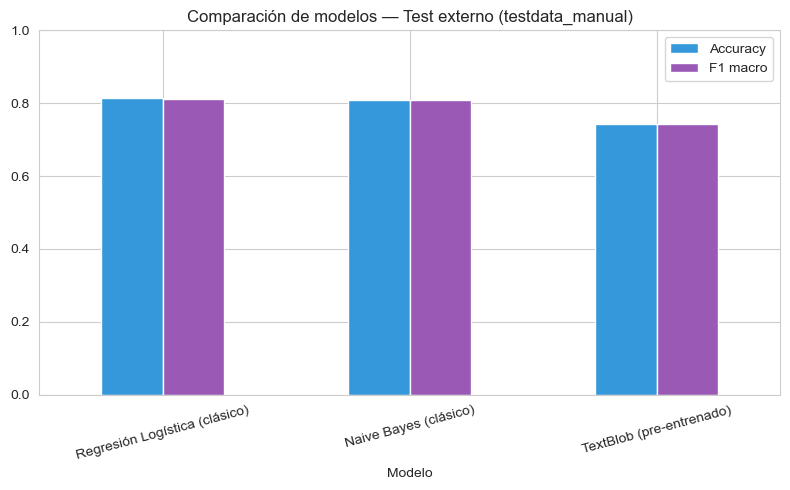

In [11]:
resultados = pd.DataFrame({
    'Modelo': ['Naive Bayes (clásico)', 'Regresión Logística (clásico)', 'TextBlob (pre-entrenado)'],
    'Accuracy': [
        accuracy_score(test_bin['label'], nb_test_pred),
        accuracy_score(test_bin['label'], lr_test_pred),
        accuracy_score(test_bin['label'], tb_test_pred),
    ],
    'F1 macro': [
        f1_score(test_bin['label'], nb_test_pred, average='macro'),
        f1_score(test_bin['label'], lr_test_pred, average='macro'),
        f1_score(test_bin['label'], tb_test_pred, average='macro'),
    ]
})
resultados = resultados.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(resultados.to_string(index=False))

fig, ax = plt.subplots(figsize=(8,5))
resultados.set_index('Modelo')[['Accuracy','F1 macro']].plot(kind='bar', ax=ax, color=['#3498db','#9b59b6'])
plt.title('Comparación de modelos — Test externo (testdata_manual)')
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('outputs_nb2_comparacion.png', dpi=110, bbox_inches='tight')
plt.show()


**Observación:** los dos modelos clásicos entrenados sobre apenas 5000 tweets superan a TextBlob (que usa un lexicón genérico pre-armado) en este test externo con tópicos de 2009 que ninguno vio en entrenamiento. Esto sugiere que, incluso con poco dato, un modelo supervisado ajustado al dominio (tweets) generaliza mejor que un lexicón genérico de propósito general. Regresión Logística es el mejor de los tres en este test.

## 8. Matrices de confusión

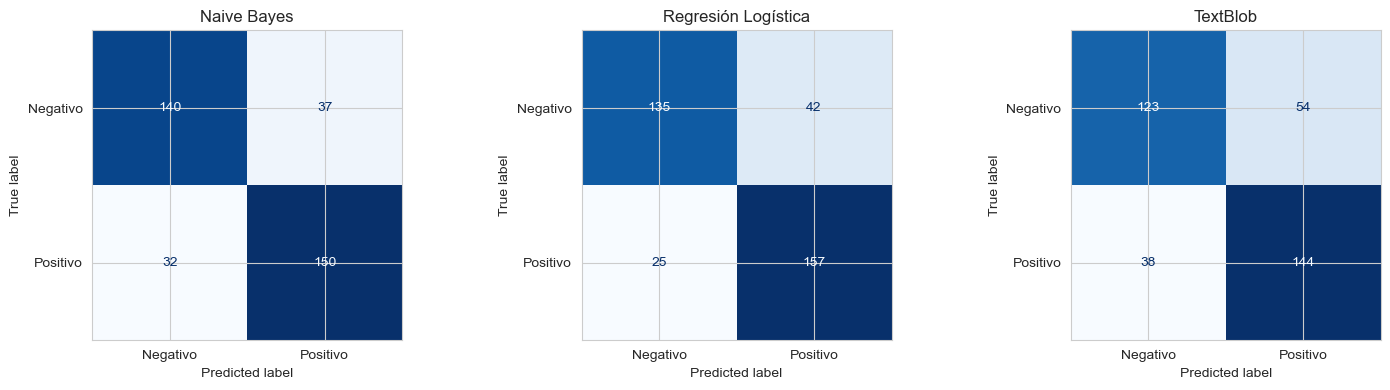

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
preds_dict = {'Naive Bayes': nb_test_pred, 'Regresión Logística': lr_test_pred, 'TextBlob': tb_test_pred}

for ax, (name, preds) in zip(axes, preds_dict.items()):
    cm = confusion_matrix(test_bin['label'], preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Negativo','Positivo'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.tight_layout()
plt.show()


## 9. ¿Qué pasa con los tweets NEUTRALES?

Nuestros modelos son binarios por diseño: nunca van a predecir "neutral" porque nunca vieron esa clase en entrenamiento. En vez de ignorar este subconjunto, lo usamos para ver **qué tan seguro/inseguro** está cada modelo frente a un caso que en la realidad es ambiguo. La expectativa razonable es que, si el modelo "entiende" algo de sentimiento, las probabilidades para los tweets neutrales deberían concentrarse más cerca de 0.5 (inseguridad) que las de los tweets claramente positivos o negativos.

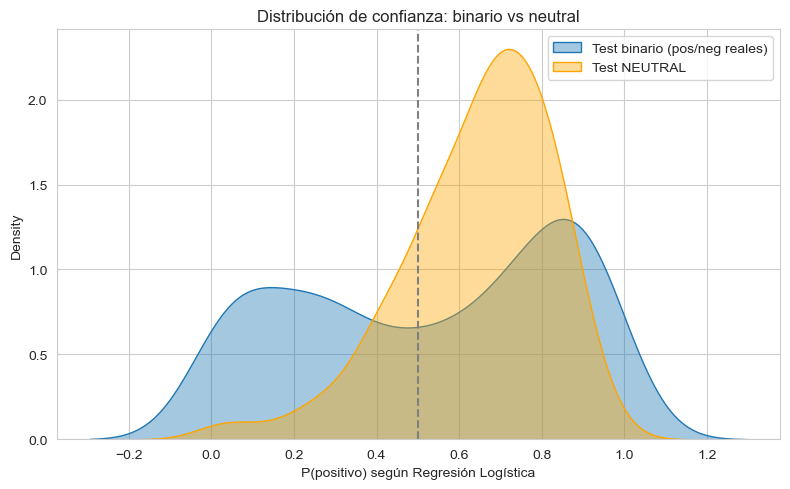

Desvío promedio respecto a 0.5 (más cerca de 0 = más inseguro):
  Test binario: 0.292
  Test neutral: 0.199


In [13]:
proba_neutral_lr = lr_model.predict_proba(Xneutral)[:,1]  # prob de "positivo"
proba_bin_lr = lr_model.predict_proba(Xtest)[:,1]

fig, ax = plt.subplots(figsize=(8,5))
sns.kdeplot(proba_bin_lr, label='Test binario (pos/neg reales)', fill=True, alpha=0.4)
sns.kdeplot(proba_neutral_lr, label='Test NEUTRAL', fill=True, alpha=0.4, color='orange')
ax.axvline(0.5, color='gray', linestyle='--')
ax.set_xlabel('P(positivo) según Regresión Logística')
ax.set_title('Distribución de confianza: binario vs neutral')
ax.legend()
plt.tight_layout()
plt.show()

print('Desvío promedio respecto a 0.5 (más cerca de 0 = más inseguro):')
print('  Test binario:', np.mean(np.abs(proba_bin_lr - 0.5)).round(3))
print('  Test neutral:', np.mean(np.abs(proba_neutral_lr - 0.5)).round(3))


**Observación:** el desvío promedio respecto a 0.5 es menor en el subconjunto neutral que en el binario, es decir, el modelo está en promedio **más inseguro** frente a tweets que un humano etiquetó como neutrales — una señal razonable de que el modelo "capta" algo de la ambigüedad real, aunque no pueda etiquetarla explícitamente por no haber visto esa clase en entrenamiento. Esta es una limitación real y esperable del diseño (train binario), no un error del modelo.

## 10. Métrica de similitud: coseno para interpretar errores

Usamos **similitud coseno** entre los vectores TF-IDF del test y del train para, frente a un tweet mal clasificado, encontrar los tweets de entrenamiento más parecidos y entender *por qué* el modelo se equivocó (ej. lenguaje ambiguo, sarcasmo, vocabulario poco representado en el train).

In [18]:
test_bin = test_bin.reset_index(drop=True)
Xtest = tfidf.transform(test_bin['clean_text'])
lr_pred_full = lr_model.predict(Xtest)
test_bin['pred'] = lr_pred_full

errores = test_bin[test_bin['label'] != test_bin['pred']]
print(f'Errores de Regresión Logística en test externo: {len(errores)} / {len(test_bin)} ({len(errores)/len(test_bin):.1%})')

# Para los primeros 3 errores, buscamos el tweet de train más similar (coseno)
idx_ejemplos = errores.index[:3]
sims = cosine_similarity(Xtest[idx_ejemplos], Xtr)

for i, idx in enumerate(idx_ejemplos):
    row = test_bin.loc[idx]
    top3 = sims[i].argsort()[::-1][:3]
    print(f"\nTweet mal clasificado (real={'Positivo' if row['label'] else 'Negativo'}, predicho={'Positivo' if row['pred'] else 'Negativo'}):")
    print(f"  '{row['text'][:100]}'")
    #print(f"  '{row['Msg_Tweet'][:100]}'")
    print('  Tweets de train más similares (coseno):')
    for rank, t in enumerate(top3):
        orig_idx = Xtr_text.index[t]
        print(f"   sim={sims[i][t]:.2f} | label={'Pos' if train.loc[orig_idx,'label'] else 'Neg'} | {train.loc[orig_idx,'Msg_Tweet'][:80]}")


Errores de Regresión Logística en test externo: 67 / 359 (18.7%)

Tweet mal clasificado (real=Negativo, predicho=Positivo):
  '@Karoli I firmly believe that Obama/Pelosi have ZERO desire to be civil.  It's a charade and a sloga'
  Tweets de train más similares (coseno):
   sim=0.63 | label=Pos | @foxandfriends Obama speaks well....but I believe Cheney had it right! 
   sim=0.61 | label=Pos | @boucher you've achieved tweetBox Zero! 
   sim=0.61 | label=Pos | Zero tolerence policy 

Tweet mal clasificado (real=Positivo, predicho=Negativo):
  '#lebron best athlete of our generation, if not all time (basketball related) I don't want to get int'
  Tweets de train más similares (coseno):
   sim=0.51 | label=Neg | i hate basketball! and sport :@ And Sports Palace 
   sim=0.47 | label=Neg | wants to get hugged! 
   sim=0.47 | label=Neg | Don't want to get upppp. 

Tweet mal clasificado (real=Positivo, predicho=Negativo):
  '@wordwhizkid Lebron is a beast... nobody in the NBA comes even close.'

**Observación:** en varios casos, el error se explica porque el tweet de test usa vocabulario poco frecuente en el train (nombres propios, jerga específica de 2009 como "Kindle2"), o porque el sentimiento depende de contexto que el TF-IDF de bag-of-words no captura bien (ironía, comparación implícita: "not that the DX is cool, but the 2 is fantastic"). La similitud coseno con los vecinos de train más cercanos nos da visibilidad honesta sobre las limitaciones de un enfoque bag-of-words.

## 11. Guardado de artefactos para el notebook 3

In [19]:
import pickle
with open('../data/processed/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
with open('../data/processed/lr_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

resultados.to_csv('../data/processed/resultados_modelos.csv', index=False)
print('Guardado: ../data/processed/tfidf_vectorizer.pkl, ../data/processed/lr_model.pkl, data/resultados_modelos.csv')


Guardado: ../data/processed/tfidf_vectorizer.pkl, ../data/processed/lr_model.pkl, data/resultados_modelos.csv


## 12. Resumen de decisiones — Notebook 2

1. Se entrenaron dos modelos clásicos (Naive Bayes, Regresión Logística) sobre TF-IDF (uni+bigramas) del train balanceado de 5000 tweets.
2. Se evaluaron ambos, más TextBlob (pre-entrenado), sobre el **mismo test externo** (`testdata_manual`, subconjunto binario 0/4) para una comparación justa.
3. **Regresión Logística resultó el mejor modelo** en el test externo, superando a TextBlob — evidencia de que un modelo ajustado al dominio, aunque entrenado con pocos datos, generaliza mejor que un lexicón genérico.
4. Se abordó la limitación de que el train es binario y el test tiene una clase neutral: en vez de ignorarla, se usó para mostrar que el modelo está, en promedio, más inseguro frente a esos casos (señal razonable de comprensión parcial de la ambigüedad).
5. Se usó **similitud coseno** entre vectores TF-IDF (train vs test) para interpretar casos mal clasificados, cumpliendo el requisito de métrica de asociación/similitud vista en clase.

**Continúa en `03_topicos_embeddings_visualizaciones.ipynb`.**